# ML Foundations – Assignment 1: Data Preparation

**Author:** Nikoloz Chachia  
**GitHub Repository:** https://github.com/nika140906/ML-fundamentals-2026

## Step 1 — Task Ordering

The tasks in this assignment are listed alphabetically, but the correct methodological order is different. Below is the order I will follow and the reason for each step.

| Step | Task | Why |
|------|------|-----|
| 1 | Identifying the Prediction Target | Must be done first so all decisions are made with the right objective in mind |
| 2 | Data Loading and Exploration | Raw data must be inspected before any transformation |
| 3 | Data Splitting | Must happen before any transformation to prevent data leakage |
| 4 | Managing Missing Values | Fitted on training set only, applied to all sets |
| 5 | Encoding Categorical Variables | Encoders must be fitted on training set only |
| 6 | Feature Scaling | Scalers must be fitted on training set only |
| 7 | Feature Selection | Computed on scaled training set only |
| 8 | Addressing Class Imbalance | Applied to training set only, last preprocessing step |
| 9 | Training Logistic Regression | Only after pipeline is complete |

### Example of Incorrect Ordering

If resampling (SMOTE) were applied before splitting the data, 
synthetic samples generated from real data points could end up 
on both sides of the split. This means the test set would contain 
data points that are not independent of the training set, giving 
an artificially optimistic evaluation of the model's performance.

## Step 2 — Identifying the Prediction Target

The target variable is **`y`** — a binary column that tells us whether 
a client subscribed to a term deposit after being contacted ('yes' or 'no').

This is the right target because the whole point of the campaign was to 
get clients to subscribe. The variable is only known after the call, 
which means it is what we are trying to predict — not something we 
already know at contact time.

### Variables that should NOT be treated as the target:

1. **`duration`** — This is how long the phone call lasted. It sounds 
useful but the problem is we only know it after the call is over. 
If we used it as a feature it would leak information about the outcome, 
and it makes no sense as a target variable either.

2. **`campaign`** — This counts how many times the client was contacted 
during the campaign. It describes what we did, not what happened as a 
result, so it is not a meaningful prediction objective.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('bank-additional.csv', sep=';')

# Display first few rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [2]:
# Dataset structure
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:")
df.describe()

Shape: (4119, 21)

Data types:
 age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Basic statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Step 3 — Data Loading and Exploration

The dataset contains 4119 rows and 21 columns. The variables are a mix 
of numerical (int64, float64) and categorical (object) types.

Numerical variables: age, duration, campaign, pdays, previous, 
emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

Categorical variables: job, marital, education, default, housing, 
loan, contact, month, day_of_week, poutcome, y

In [3]:
# Target variable distribution
print("Target variable distribution:")
print(df['y'].value_counts())
print("\nPercentage:")
print(df['y'].value_counts(normalize=True).round(3) * 100)

Target variable distribution:
y
no     3668
yes     451
Name: count, dtype: int64

Percentage:
y
no     89.1
yes    10.9
Name: proportion, dtype: float64


The target variable is heavily imbalanced — 89.1% of clients did not 
subscribe and only 10.9% did. This means a model that always predicts 
"no" would be 89% accurate, which is misleading. We will need to address 
this imbalance later using resampling on the training set only.

In [4]:
# Check for explicit missing values
print("Explicit missing values (NaN):")
print(df.isnull().sum())

# Check for implicit missing values (unknown categories)
print("\nImplicit missing values ('unknown'):")
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count}")

Explicit missing values (NaN):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Implicit missing values ('unknown'):
job: 39
marital: 11
education: 167
default: 803
housing: 105
loan: 105


There are no explicit missing values (NaN) in the dataset. However, 
several categorical columns contain the value 'unknown' which represents 
implicit missing values — data that was not collected or not available.

The most affected columns are:
- default: 803 unknown values (19.5% of rows)
- education: 167 unknown values
- housing and loan: 105 each
- job: 39 unknown values
- marital: 11 unknown values

We will handle these in Step 5 (Managing Missing Values) after splitting 
the data, to avoid any leakage into the validation and test sets.

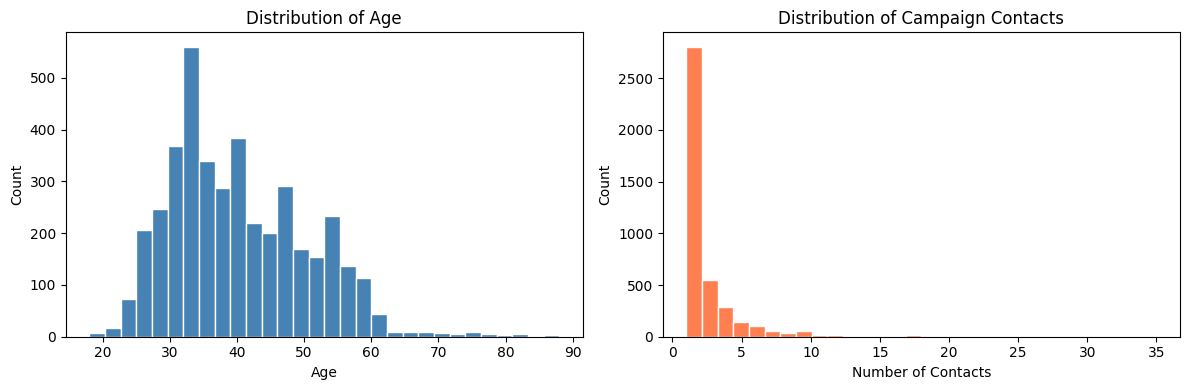

In [5]:
# Visualize two numerical variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Campaign distribution
axes[1].hist(df['campaign'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Campaign Contacts')
axes[1].set_xlabel('Number of Contacts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The age distribution is roughly bell-shaped, with most clients between 
25 and 50 years old. The campaign variable is heavily right-skewed — 
most clients were contacted only once or twice, but a small number were 
contacted up to 35 times. This extreme skewness in campaign will need 
to be considered during feature scaling.

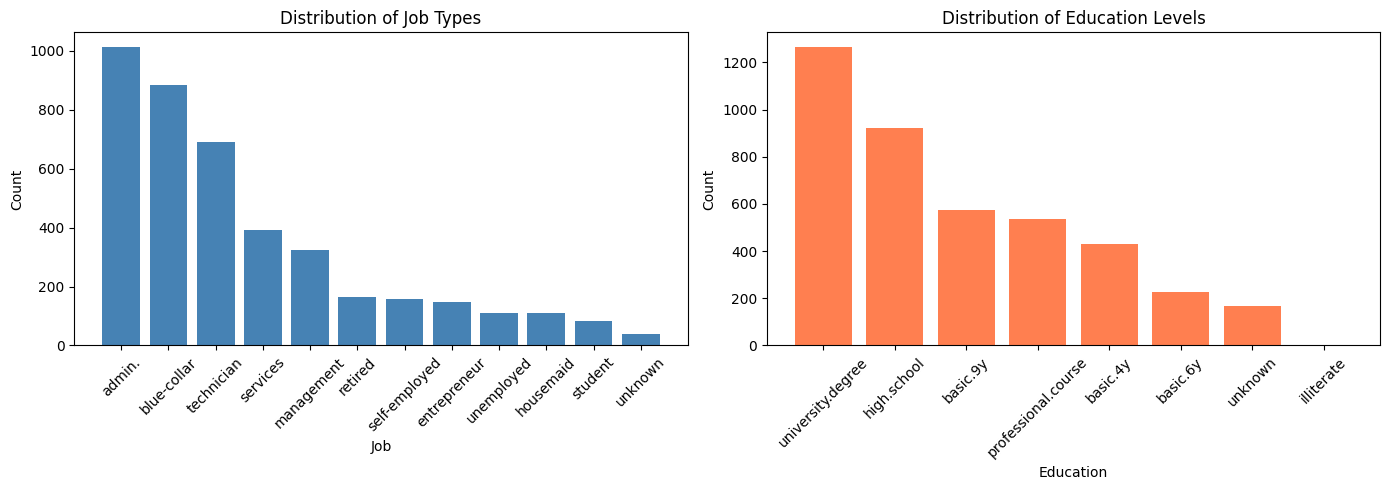

In [6]:
# Visualize two categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Job distribution
job_counts = df['job'].value_counts()
axes[0].bar(job_counts.index, job_counts.values, color='steelblue')
axes[0].set_title('Distribution of Job Types')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Education distribution
edu_counts = df['education'].value_counts()
axes[1].bar(edu_counts.index, edu_counts.values, color='coral')
axes[1].set_title('Distribution of Education Levels')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The most common job types are admin, blue-collar and technician. 
The education plot shows that most clients have a university degree 
or high school education. We can also clearly see the 'unknown' 
category in both plots, confirming the implicit missing values 
we identified earlier.

### Variable Requiring Special Consideration

**`duration`** — This variable records how long the phone call lasted. 
It is strongly correlated with the outcome (longer calls tend to result 
in subscriptions) but it is only known after the call ends. This means 
it cannot be used as a feature at prediction time — using it would 
cause data leakage. We will remove it from the feature set before 
training the model.